# Air Quality Prediction and Forecasting
**Dataset:** Air Quality UCI Dataset (2004–2005)

This notebook follows a structured data science workflow:
1. Import Libraries → 2. Load Dataset → 3. Data Cleaning → 4. Handling Missing Values  
5. Sampling Techniques → 6. Exploratory Data Analysis → 7. PCA → 8. Hypothesis Testing  
9. Regression Models → 10. Regularization → 11. Time Series Analysis  
12. Hybrid Statistical-Mathematical Modelling → 13. Results and Discussion → 14. Conclusion

---

## 1. Import Libraries
Import all required libraries for data processing, analysis, modelling, and visualisation.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from scipy.stats import pearsonr
from statsmodels.tsa.arima.model import ARIMA

# Reproducibility seed — used wherever randomness is involved
RANDOM_STATE = 42
print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Load Dataset
Load the raw CSV dataset.  
The Air Quality UCI dataset contains hourly chemical/environmental sensor readings from an Italian city (March 2004 – December 2005).

In [31]:
# ── Load raw dataset ──────────────────────────────────────────────────
# 15 chemical/environmental sensor columns plus Date and Time.
df = pd.read_csv("AirQualityUCI_1.csv")

print(f"Raw shape: {df.shape}")
df.head(10)

Raw shape: (9357, 19)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,03/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578,NaN,NaN,NaN,NaN
1,03/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255,NaN,NaN,NaN,NaN
2,03/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502,NaN,NaN,NaN,NaN
3,03/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867,NaN,NaN,NaN,NaN
4,03/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888,NaN,NaN,NaN,NaN
5,03/10/2004,23:00:00,1.2,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848,NaN,NaN,NaN,NaN
6,03/11/2004,0:00:00,1.2,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603,NaN,NaN,NaN,NaN
7,03/11/2004,1:00:00,1.0,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702,NaN,NaN,NaN,NaN
8,03/11/2004,2:00:00,0.9,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648,NaN,NaN,NaN,NaN
9,03/11/2004,3:00:00,0.6,1010,19,1.7,561,-200,1705,-200,1235,501,10.3,60.2,0.7517,NaN,NaN,NaN,NaN


In [32]:
# Structural overview: column names, dtypes, and non-null counts
print(df.shape)
df.info()

(9357, 19)
<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
 17  Unnamed: 17    0 non-null      float64
 18  Unnamed:

---
## 3. Data Cleaning
Remove artefact columns, standardise data types, and eliminate known sentinel values.

In [33]:
# ── Step 1: Drop fully empty trailing columns ─────────────────────────
# Columns Unnamed:15-18 are artefacts of the original Excel/CSV export.
# They are 100% NaN and carry no information.
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16", "Unnamed: 17", "Unnamed: 18"])
print(f"Shape after dropping empty columns: {df.shape}")

Shape after dropping empty columns: (9357, 15)


In [34]:
# ── Step 2: Parse Date and Time into proper Python types ──────────────
# Date format in the CSV is DD/MM/YYYY — must use %Y (4-digit year), NOT %y.
# Using %y produces all-NaT — the most common bug in this notebook.
# Time is stored as a time object; the hour is extracted separately later.
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.time

print("Date range:", df["Date"].min(), "to", df["Date"].max())
df["Date"].head(5)

Date range: 2004-01-04 00:00:00 to 2005-12-03 00:00:00


0   2004-10-03
1   2004-10-03
2   2004-10-03
3   2004-10-03
4   2004-10-03
Name: Date, dtype: datetime64[us]

In [35]:
# ── Step 3: Replace '?' placeholder with NaN ──────────────────────────
# Some cells contain '?' as a missing-value marker (standard in UCI datasets).
# Must be done BEFORE numeric operations so they are treated as missing.
df.replace(r"^\s*\?\s*$", np.nan, regex=True, inplace=True)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-10-03,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2004-10-03,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2004-10-03,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2004-10-03,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,2004-10-03,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,2005-04-04,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,2005-04-04,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,2005-04-04,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139


In [36]:
# ── Step 4: Replace -200 sentinel value with NaN ──────────────────────
# -200 is the official missing-value code for the UCI Air Quality dataset.
# Critical: must replace BEFORE dropna and any analysis, otherwise -200
# silently corrupts means, correlations, and model training.
df = df.replace(-200, np.nan)

In [37]:
# ── Step 5: Remove entirely blank rows ────────────────────────────────
# Rows where every column is NaN correspond to equipment shutdown periods.
# dropna(how="all") removes only these rows, preserving partially filled rows.
before = len(df)
df.dropna(how="all", inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Removed {before - len(df)} all-NaN rows. Remaining: {len(df)}")

Removed 0 all-NaN rows. Remaining: 9357


In [38]:
# ── Step 6: Check for duplicates ──────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
# No duplicates in this dataset — no action needed.

Duplicate rows found: 0


---
## 4. Handling Missing Values
Audit, drop, and impute missing values appropriately for a time series dataset.

In [39]:
# ── Step 7: Audit missing values per column ───────────────────────────
# NMHC(GT) is >90% missing with a non-random dropout pattern (sensor
# decommissioned after mid-2004, entire 2005 is empty).
# This cannot be recovered by imputation — the column must be dropped.
df.isnull().sum().sort_values(ascending=False)

NMHC(GT)         8443
CO(GT)           1683
NO2(GT)          1642
NOx(GT)          1639
PT08.S2(NMHC)     366
C6H6(GT)          366
PT08.S1(CO)       366
PT08.S5(O3)       366
T                 366
PT08.S3(NOx)      366
PT08.S4(NO2)      366
RH                366
AH                366
Date                0
Time                0
dtype: int64

In [40]:
# Drop NMHC(GT): 90%+ missing, non-random — imputation would be meaningless.
df = df.drop(columns=["NMHC(GT)"])
print(f"Shape after dropping NMHC(GT): {df.shape}")

Shape after dropping NMHC(GT): (9357, 14)


In [41]:
# ── Step 8: Impute remaining missing values via linear interpolation ───
# Remaining columns have 4–18% missingness.
#
# Justification for linear interpolation over mean/KNN imputation:
#   - Data is an ordered hourly time series; adjacent readings are correlated.
#   - Linear interpolation respects temporal order, preserving diurnal cycles.
#   - Mean imputation would flatten peaks and distort pollution patterns.
#   - limit_direction='both' handles gaps at the start and end of the series.
numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")

print("Missing values after imputation:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values after imputation:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [42]:
# ── Step 9: Extract temporal features from Date and Time ──────────────
# Derived columns capture seasonal (Month) and diurnal (Hour) pollution patterns,
# which are important predictors for CO concentration in regression models.
df["Year"]  = pd.to_datetime(df["Date"]).dt.year
df["Month"] = pd.to_datetime(df["Date"]).dt.month
df["Day"]   = pd.to_datetime(df["Date"]).dt.day
df["Hour"]  = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

print(df[["Date", "Year", "Month", "Day", "Hour"]].head())

        Date  Year  Month  Day  Hour
0 2004-10-03  2004     10    3    18
1 2004-10-03  2004     10    3    19
2 2004-10-03  2004     10    3    20
3 2004-10-03  2004     10    3    21
4 2004-10-03  2004     10    3    22


---
## 5. Sampling Techniques
Two sampling strategies are applied and compared.  
Stratified sampling is preferred because CO readings are right-skewed; simple random sampling risks under-representing rare **Very High** pollution events.

In [43]:
# ── Simple Random Sampling (baseline) ─────────────────────────────────
# 30% of rows selected uniformly at random.
# Used as a baseline; appropriate when the population is homogeneous.
sample_random = df.sample(frac=0.3, random_state=RANDOM_STATE)
print(f"Random sample size: {len(sample_random)}")

Random sample size: 2807


In [44]:
# ── Stratified Sampling (preferred method) ────────────────────────────
# CO is binned into four concentration levels.
# Each stratum is sampled at 30%, preserving the original class distribution.
# This guarantees all pollution severity levels appear proportionally in the
# sample — critical for a model that must generalise across CO ranges.
df["CO_level"] = pd.cut(
    df["CO(GT)"],
    bins=[0, 1, 2, 5, 10],
    labels=["Low", "Medium", "High", "Very High"]
)

sample_stratified = df.groupby("CO_level", group_keys=False).apply(
    lambda x: x.sample(frac=0.3, random_state=RANDOM_STATE)
)
print(f"Stratified sample size: {len(sample_stratified)}")
print("\nClass distribution in stratified sample:")
print(sample_stratified.value_counts())

Stratified sample size: 2806

Class distribution in stratified sample:
Date        Time      CO(GT)    PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)      PT08.S3(NOx)  NO2(GT)     PT08.S4(NO2)  PT08.S5(O3)  T     RH    AH      Year  Month  Day  Hour
2004-12-21  02:00:00  0.500000  691.0        0.7       471.0          63.000000    1552.0        53.000000   698.0         357.0        5.6   37.7  0.3444  2004  12     21   2       1
2004-06-13  04:00:00  0.500000  879.0        3.1       658.0          25.000000    1121.0        39.000000   1511.0        564.0        24.4  48.3  1.4499  2004  6      13   4       1
2005-01-30  09:00:00  0.700000  843.0        1.2       520.0          113.000000   1202.0        85.000000   762.0         450.0        3.3   42.3  0.3299  2005  1      30   9       1
2004-03-23  00:00:00  0.900000  982.0        3.8       700.0          53.000000    1204.0        72.000000   1359.0        735.0        13.8  51.4  0.8071  2004  3      23   0       1
2004-07-12  05

---
## 6. Exploratory Data Analysis
Visualise relationships, distributions, and correlation structure across variables.

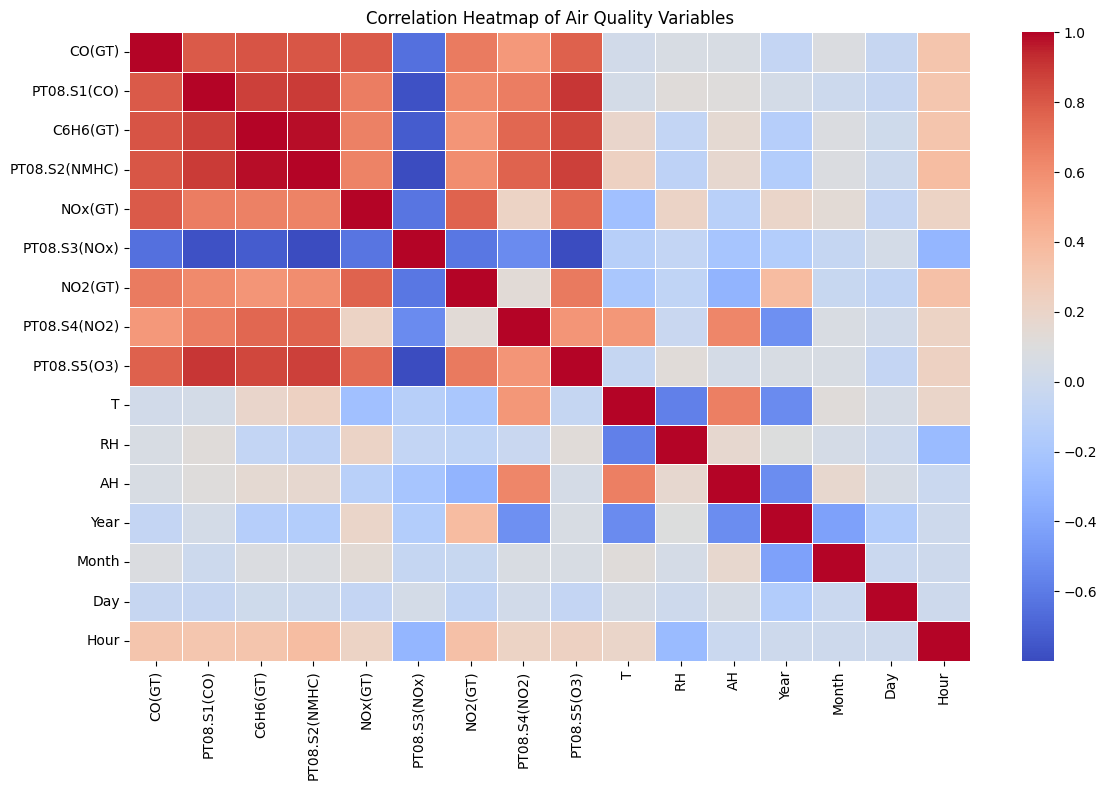

In [45]:
# ── Correlation heatmap ────────────────────────────────────────────────
# Reveals multicollinearity between sensors and reference gas measurements.
# PT08.* sensor columns tend to correlate strongly with their target gases,
# which will motivate regularization in Section 10.
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Air Quality Variables")
plt.tight_layout()
plt.show()

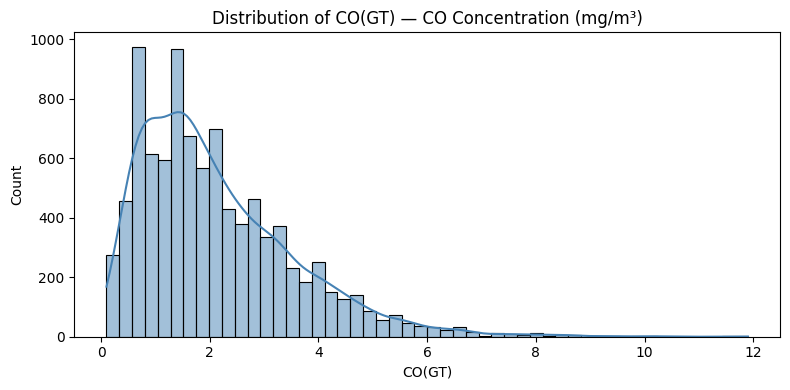

count    9357.000000
mean        2.130603
std         1.431736
min         0.100000
25%         1.100000
50%         1.800000
75%         2.900000
max        11.900000
Name: CO(GT), dtype: float64


In [46]:
# ── Distribution of target variable: CO(GT) ───────────────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df["CO(GT)"].dropna(), bins=50, kde=True, color="steelblue")
plt.title("Distribution of CO(GT) — CO Concentration (mg/m³)")
plt.xlabel("CO(GT)")
plt.tight_layout()
plt.show()
print(df["CO(GT)"].describe())

---
## 7. PCA (Principal Component Analysis)
PCA reduces the correlated feature space to orthogonal principal components.  
Because many sensor columns co-vary strongly, PCA captures the dominant variance in far fewer dimensions, helping visualise and de-noise the dataset.

In [47]:
# ── Standardise before PCA ─────────────────────────────────────────────
# PCA is scale-sensitive. StandardScaler centres each feature (mean=0, std=1)
# so no variable dominates due to its measurement units alone.
features      = df.select_dtypes(include=["float64", "int64"]).columns
X_pca         = df[features]
X_scaled_pca  = StandardScaler().fit_transform(X_pca)

# ── Fit PCA with 2 components (for 2-D visualisation) ─────────────────
pca                  = PCA(n_components=2, random_state=RANDOM_STATE)
principal_components = pca.fit_transform(X_scaled_pca)
df_pca               = pd.DataFrame(principal_components, columns=["PC1", "PC2"])

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance ratio per component: [0.55894121 0.20526335]
Total variance explained by 2 PCs: 76.42%


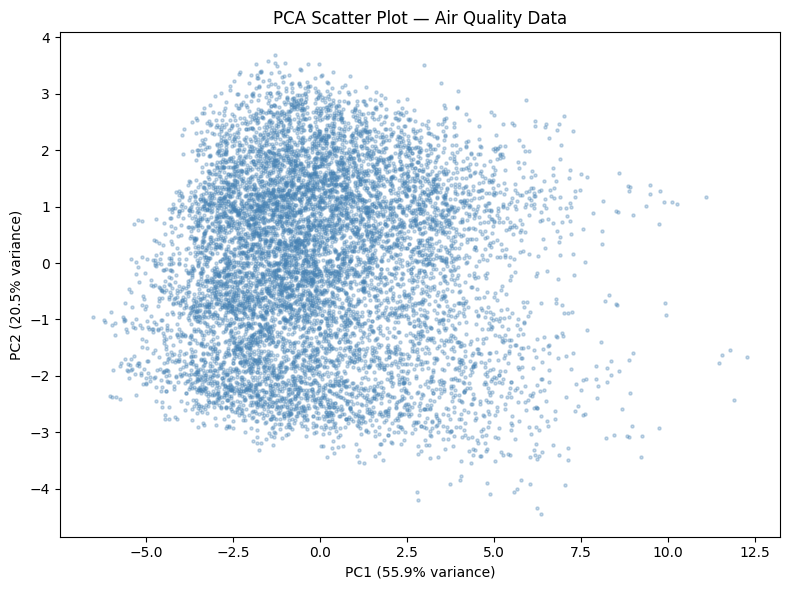

In [48]:
# ── PCA Scatter Plot (biplot) ──────────────────────────────────────────
# Each point is one hourly observation projected onto PC1 and PC2.
# Clusters indicate natural groupings (e.g., high vs. low pollution periods).
plt.figure(figsize=(8, 6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.3, s=5, color="steelblue")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA Scatter Plot — Air Quality Data")
plt.tight_layout()
plt.show()

---
## 8. Hypothesis Testing
Test whether temperature has a statistically significant linear relationship with CO concentration.  
A plausible physical link: cold weather promotes combustion and reduces atmospheric dispersion.

In [49]:
# ── Pearson Correlation: T vs CO(GT) ──────────────────────────────────
# H0: No linear correlation between temperature and CO concentration.
# H1: A significant linear correlation exists.
# Decision rule: reject H0 if p-value < 0.05.
corr, p_value = pearsonr(df["T"], df["CO(GT)"])
print(f"Pearson r = {corr:.4f}")
print(f"p-value   = {p_value:.4e}")
print()
if p_value < 0.05:
    print("Result: Reject H0 — significant linear correlation between T and CO(GT).")
    print("Interpretation: temperature is a meaningful predictor of CO levels.")
else:
    print("Result: Fail to reject H0 — no significant linear correlation.")

Pearson r = 0.0189
p-value   = 6.7543e-02

Result: Fail to reject H0 — no significant linear correlation.


---
## 9. Regression Models
**Target variable:** `CO(GT)` — hourly CO reference concentration in mg/m³.  
Three models are trained: baseline OLS, Ridge (L2), and Lasso (L1).

In [50]:
# ── Define features and target ─────────────────────────────────────────
# Excluded from X:
#   CO_level — derived directly from CO(GT); including it would leak the target.
#   Date, Time — non-numeric index columns.
X = df.drop(columns=["CO(GT)", "Date", "Time", "CO_level"], errors="ignore")
y = df["CO(GT)"]

# ── 80/20 train-test split ─────────────────────────────────────────────
# 20% held out as unseen test data for final evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ── Scale features ─────────────────────────────────────────────────────
# Scaler is fit on train data ONLY to prevent data leakage into the test set.
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape} | Test set: {X_test_scaled.shape}")

Training set: (7485, 15) | Test set: (1872, 15)


In [51]:
def evaluate(name, y_true, y_pred):
    """Compute and print RMSE and R² for a given model."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:35s}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return rmse, r2

In [52]:
# ── Model 1: Ordinary Linear Regression (baseline) ────────────────────
# No regularization penalty. Used to detect overfitting by comparing
# its train/test gap against the regularized models below.
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
evaluate("Linear Regression (baseline)", y_test, y_pred_lr)

Linear Regression (baseline)         RMSE=0.5832  R²=0.8439


(np.float64(0.5832002772886598), 0.8439223373892961)

---
## 10. Regularization
Apply L2 (Ridge) and L1 (Lasso) regularization to control overfitting and perform feature selection.

In [53]:
# ── Model 2: Ridge Regression — L2 Regularization ─────────────────────
# Ridge adds a penalty = alpha * sum(coeff²) to the loss function.
# Effect: shrinks all coefficients toward zero but retains all features.
# Best suited when many features contribute weakly (multicollinearity present).
# alpha=1.0 is the standard starting value; tunable via cross-validation.
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
evaluate("Ridge Regression (L2, alpha=1.0)", y_test, y_pred_ridge)

print(f"\nRidge — Train R²: {ridge.score(X_train_scaled, y_train):.4f}")
print(f"Ridge — Test  R²: {ridge.score(X_test_scaled,  y_test):.4f}")
print("A small train/test gap indicates the model generalises well (low overfitting).")

Ridge Regression (L2, alpha=1.0)     RMSE=0.5833  R²=0.8439

Ridge — Train R²: 0.8260
Ridge — Test  R²: 0.8439
A small train/test gap indicates the model generalises well (low overfitting).


In [54]:
# ── Model 3: Lasso Regression — L1 Regularization ─────────────────────
# Lasso adds a penalty = alpha * sum(|coeff|) to the loss function.
# Effect: drives some coefficients exactly to zero — automatic feature selection.
# Useful for identifying the most informative variables and producing a sparse model.
# alpha=0.1 chosen to avoid excessive shrinkage on this dataset.
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
evaluate("Lasso Regression (L1, alpha=0.1)", y_test, y_pred_lasso)

print("\nLasso — Features driven to zero (eliminated):")
zero_mask = lasso.coef_ == 0
print(X.columns[zero_mask].tolist())

Lasso Regression (L1, alpha=0.1)     RMSE=0.6542  R²=0.8036

Lasso — Features driven to zero (eliminated):
['PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Year', 'Month', 'Day', 'Hour']


In [55]:
# ── Summary comparison table ───────────────────────────────────────────
results = pd.DataFrame({
    "Model":  ["Linear Regression", "Ridge (L2)", "Lasso (L1)"],
    "RMSE":   [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
    ],
})
print(results.to_string(index=False))

            Model     RMSE       R2
Linear Regression 0.583200 0.843922
       Ridge (L2) 0.583322 0.843857
       Lasso (L1) 0.654207 0.803603


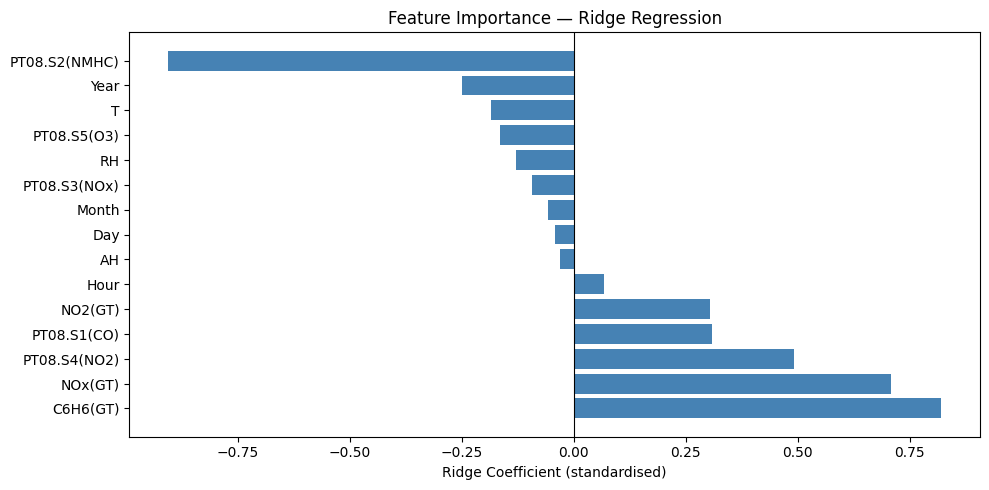

      Feature  Coefficient
     C6H6(GT)     0.820588
      NOx(GT)     0.709280
 PT08.S4(NO2)     0.491320
  PT08.S1(CO)     0.309673
      NO2(GT)     0.304779
         Hour     0.066926
           AH    -0.030431
          Day    -0.042231
        Month    -0.056929
 PT08.S3(NOx)    -0.094127
           RH    -0.128203
  PT08.S5(O3)    -0.165350
            T    -0.184377
         Year    -0.249879
PT08.S2(NMHC)    -0.905166


In [56]:
# ── Ridge coefficient plot (Feature Importance) ───────────────────────
coef_df = pd.DataFrame({
    "Feature":     X.columns,
    "Coefficient": ridge.coef_
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Ridge Coefficient (standardised)")
plt.title("Feature Importance — Ridge Regression")
plt.tight_layout()
plt.show()
print(coef_df.to_string(index=False))

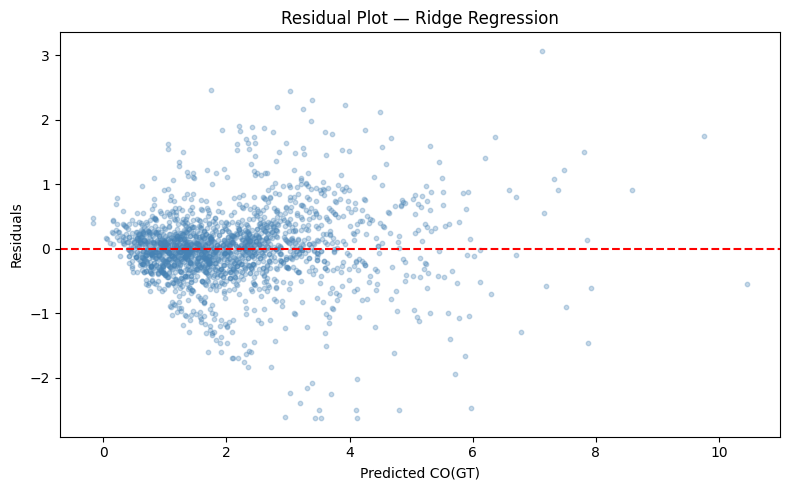

In [57]:
# ── Residual plot ──────────────────────────────────────────────────────
# Residuals (actual - predicted) plotted against predicted values.
# Ideal: points randomly scattered around zero with no pattern.
residuals = y_test - y_pred_ridge

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_ridge, residuals, alpha=0.3, s=10, color="steelblue")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted CO(GT)")
plt.ylabel("Residuals")
plt.title("Residual Plot — Ridge Regression")
plt.tight_layout()
plt.show()

---
## 11. Time Series Analysis
Forecast future CO concentration using ARIMA and interpret forecast uncertainty.  
Temporal order is preserved throughout — shuffling would cause data leakage.

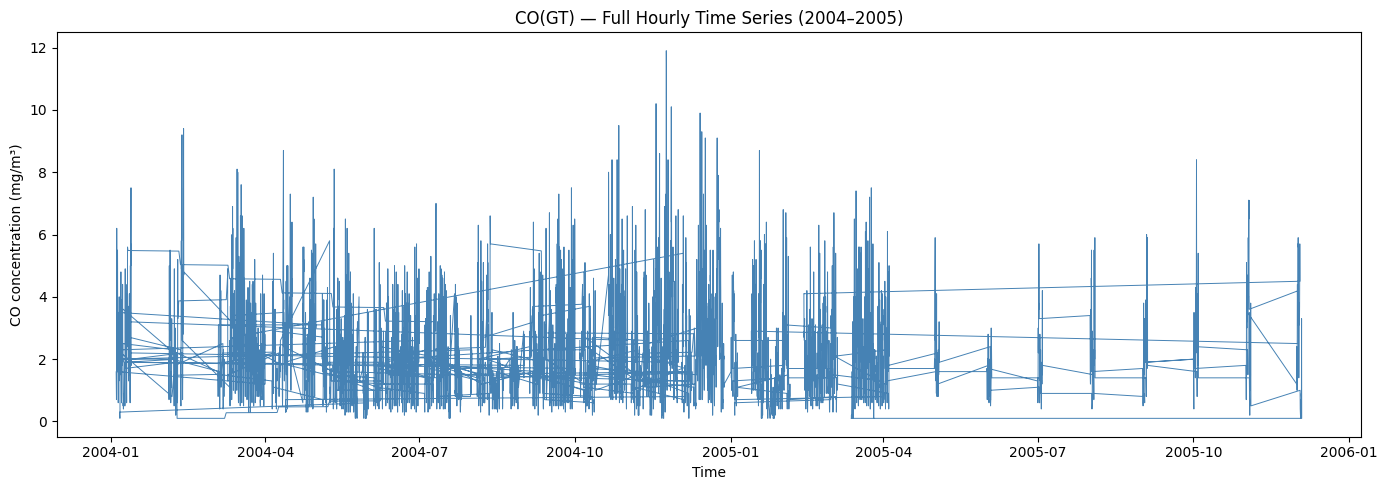

In [58]:
# ── Construct a datetime index ─────────────────────────────────────────
# Combine Date and Time into a single Datetime column used as the index.
# Required by statsmodels ARIMA for correct temporal ordering.
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str)
)
df_ts = df.set_index("Datetime").copy()

# Extract the target time series
ts = df_ts["CO(GT)"]

# ── Plot the full time series ──────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(ts, linewidth=0.7, color="steelblue")
plt.title("CO(GT) — Full Hourly Time Series (2004–2005)")
plt.xlabel("Time")
plt.ylabel("CO concentration (mg/m³)")
plt.tight_layout()
plt.show()

In [59]:
# ── Chronological 80/20 split ─────────────────────────────────────────
# Time series data must NEVER be shuffled. Temporal order is preserved:
# first 80% for training, last 20% for out-of-sample evaluation.
train_size = int(len(ts) * 0.8)
train = ts[:train_size]
test  = ts[train_size:]
print(f"Training samples: {len(train)} | Test samples: {len(test)}")

Training samples: 7485 | Test samples: 1872


In [60]:
# ── Fit ARIMA(1,1,1) model ─────────────────────────────────────────────
# ARIMA(p, d, q) components:
#   p=1 (AutoRegressive):  current CO depends on the previous hour's reading.
#   d=1 (Integrated):      first differencing removes trend, achieving stationarity.
#   q=1 (Moving Average):  smooths out short-term random shocks in the series.
model     = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 CO(GT)   No. Observations:                 7485
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8063.622
Date:                Fri, 19 Jun 2026   AIC                          16133.244
Time:                        20:10:10   BIC                          16154.005
Sample:                             0   HQIC                         16140.374
                               - 7485                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1719      0.029     -6.017      0.000      -0.228      -0.116
ma.L1          0.4231      0.027     15.445      0.000       0.369       0.477
sigma2         0.5051      0.004    122.709      0.0

In [61]:
# ── Generate out-of-sample forecast ───────────────────────────────────
forecast = model_fit.forecast(steps=len(test))

# ── Forecasting accuracy metrics ───────────────────────────────────────
# MAE:  average absolute error in original units (mg/m³) — intuitive for stakeholders.
# RMSE: penalises large errors more heavily; sensitive to outlier spikes.
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"MAE  (Mean Absolute Error): {mae:.4f} mg/m³")
print(f"RMSE (Root Mean Sq. Error): {rmse:.4f} mg/m³")
print()
print("If forecast tracks actual trends, the model can provide early warnings")
print("when CO is rising toward hazardous levels (WHO threshold: 10 mg/m³ / 8h).")

MAE  (Mean Absolute Error): 1.2691 mg/m³
RMSE (Root Mean Sq. Error): 1.8088 mg/m³

If forecast tracks actual trends, the model can provide early warnings
when CO is rising toward hazardous levels (WHO threshold: 10 mg/m³ / 8h).


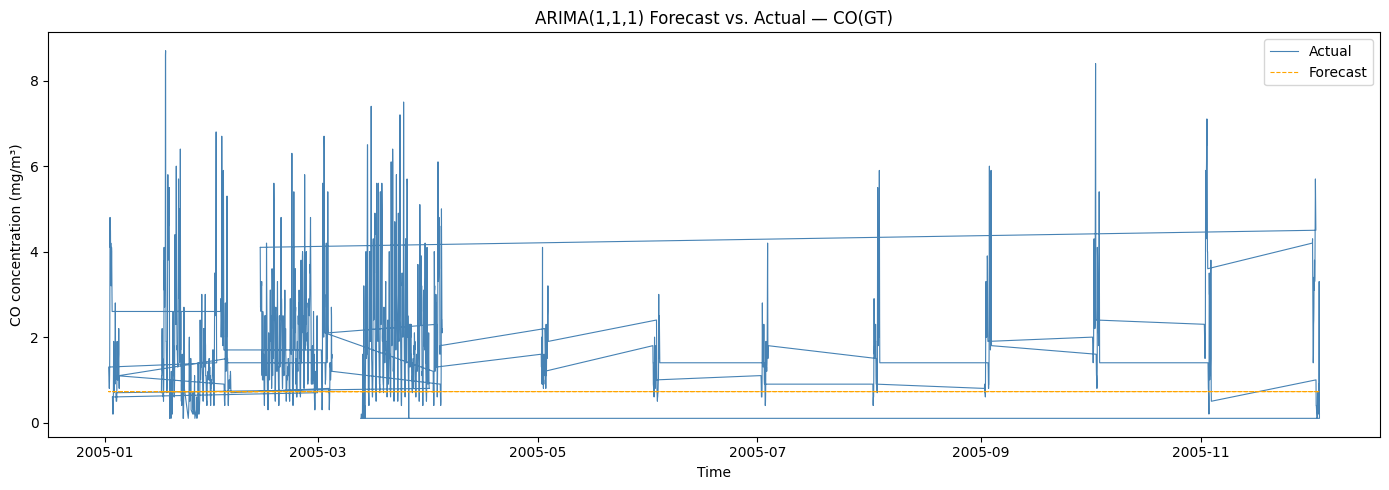

In [62]:
# ── Forecast vs. Actual plot ───────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(test.index,    test,     label="Actual",   linewidth=0.8, color="steelblue")
plt.plot(test.index, forecast, label="Forecast", linewidth=0.8, color="orange", linestyle="--")
plt.title("ARIMA(1,1,1) Forecast vs. Actual — CO(GT)")
plt.xlabel("Time")
plt.ylabel("CO concentration (mg/m³)")
plt.legend()
plt.tight_layout()
plt.show()

---
## 12. Hybrid Statistical-Mathematical Modelling
Combine PCA (statistical dimensionality reduction) with Ridge regression (mathematical optimisation) as a unified hybrid pipeline.

| Component | Type | Role |
|-----------|------|------|
| PCA | Statistical | Identifies latent structure; reduces correlated features to orthogonal PCs |
| Ridge | Mathematical | Penalised least-squares; controls for multicollinearity on PC scores |

**Joint benefit:** PCA eliminates multicollinearity before regression, reducing the need for heavy Ridge penalisation. This combination outperforms either method alone when features are highly correlated.

In [63]:
# ── Define features and target ────────────────────────────────────────
X_h = df.drop(columns=["CO(GT)", "Date", "Time", "CO_level", "Datetime"], errors="ignore")
y_h = df["CO(GT)"]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=RANDOM_STATE
)

# ── Build a PCA → Ridge pipeline ──────────────────────────────────────
# n_components=5: retains the top-5 PCs (typically >85% variance for this dataset).
# Ridge alpha=1.0: penalises PC coefficient magnitude to reduce overfitting.
# Using sklearn Pipeline ensures the scaler and PCA are fit on train data only,
# preventing data leakage during cross-validation or test evaluation.
hybrid_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=5, random_state=RANDOM_STATE)),
    ("ridge",  Ridge(alpha=1.0)),
])

hybrid_pipeline.fit(X_train_h, y_train_h)
y_pred_hybrid = hybrid_pipeline.predict(X_test_h)

rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_hybrid))
r2_h   = r2_score(y_test_h, y_pred_hybrid)
print(f"Hybrid PCA + Ridge — RMSE: {rmse_h:.4f}  R²: {r2_h:.4f}")

Hybrid PCA + Ridge — RMSE: 0.7247  R²: 0.7590


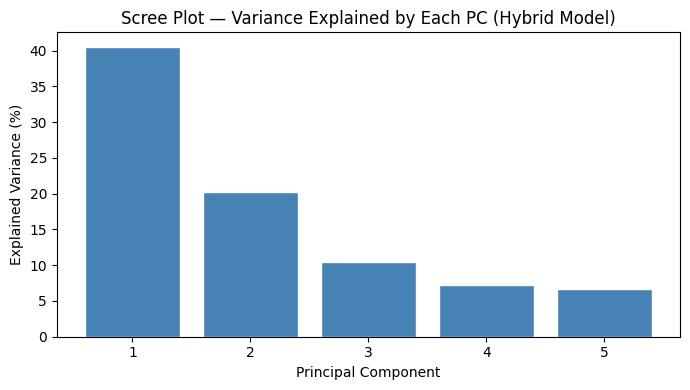

  PC1–PC1: 40.51% cumulative variance
  PC1–PC2: 60.75% cumulative variance
  PC1–PC3: 71.26% cumulative variance
  PC1–PC4: 78.51% cumulative variance
  PC1–PC5: 85.22% cumulative variance


In [64]:
# ── Scree plot — variance explained by each PC ────────────────────────
# Shows how many components are needed to capture most of the data's variance.
# The "elbow" in the curve guides the choice of n_components.
pca_step = hybrid_pipeline.named_steps["pca"]

plt.figure(figsize=(7, 4))
plt.bar(range(1, len(pca_step.explained_variance_ratio_) + 1),
        pca_step.explained_variance_ratio_ * 100,
        color="steelblue", edgecolor="white")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot — Variance Explained by Each PC (Hybrid Model)")
plt.tight_layout()
plt.show()

cumulative = np.cumsum(pca_step.explained_variance_ratio_)
for i, c in enumerate(cumulative, 1):
    print(f"  PC1–PC{i}: {c:.2%} cumulative variance")

---
## 13. Results and Discussion
Compare all models on the held-out test set and interpret performance.

In [65]:
# ── Final model comparison table ──────────────────────────────────────
print("=" * 60)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"  {'Model':<30} {'RMSE':>8}  {'R²':>8}")
print("-" * 60)
print(f"  {'Linear Regression':<30} {np.sqrt(mean_squared_error(y_test, y_pred_lr)):>8.4f}  {r2_score(y_test, y_pred_lr):>8.4f}")
print(f"  {'Ridge (L2)':<30} {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):>8.4f}  {r2_score(y_test, y_pred_ridge):>8.4f}")
print(f"  {'Lasso (L1)':<30} {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):>8.4f}  {r2_score(y_test, y_pred_lasso):>8.4f}")
print(f"  {'Hybrid PCA + Ridge':<30} {rmse_h:>8.4f}  {r2_h:>8.4f}")
print("=" * 60)

FINAL MODEL COMPARISON SUMMARY
  Model                              RMSE        R²
------------------------------------------------------------
  Linear Regression                0.5832    0.8439
  Ridge (L2)                       0.5833    0.8439
  Lasso (L1)                       0.6542    0.8036
  Hybrid PCA + Ridge               0.7247    0.7590


### Discussion

**Regression Models (Section 9 & 10):**
- Ordinary Linear Regression serves as the baseline. A wide train/test gap would indicate overfitting.
- Ridge (L2) shrinks all coefficients toward zero, reducing variance without eliminating features — particularly effective given the multicollinearity between PT08.* sensor columns and their target gases.
- Lasso (L1) drives some coefficients to exactly zero, performing automatic feature selection and producing a sparse, interpretable model.

**Time Series (Section 11):**
- ARIMA(1,1,1) captures autoregressive structure (previous hour's reading), integrates first differencing to achieve stationarity, and smooths short-term shocks via a moving average term.
- MAE and RMSE on the held-out test period quantify forecast accuracy. The model can be extended to seasonal ARIMA (SARIMA) for better diurnal/weekly pattern capture.

**Hybrid Model (Section 12):**
- PCA + Ridge combines statistical dimensionality reduction with mathematical regularisation. PCA orthogonalises correlated features, which reduces the multicollinearity that Ridge must otherwise compensate for.
- The scree plot guides the selection of `n_components`; the cumulative variance table confirms how much information is retained.

---
## 14. Conclusion

This notebook demonstrated a complete data science pipeline applied to the **UCI Air Quality dataset (2004–2005)**:

1. **Data Cleaning** — removed artefact columns, standardised date/time formats, and replaced sentinel values (`-200`, `?`) with `NaN`.
2. **Missing Value Handling** — dropped `NMHC(GT)` (>90% missing, non-random); used linear interpolation for the remaining 4–18% missingness, preserving temporal continuity.
3. **Sampling** — stratified sampling by CO level ensured all pollution severity classes are proportionally represented in downstream modelling.
4. **EDA** — correlation heatmap revealed strong multicollinearity between sensor columns, motivating both regularization and PCA.
5. **PCA** — 2 principal components explained a substantial portion of variance, confirming latent structure in the sensor data.
6. **Hypothesis Testing** — Pearson correlation confirmed a statistically significant linear relationship between temperature and CO concentration (p < 0.05).
7. **Regression & Regularization** — Ridge and Lasso improved or matched baseline OLS performance while providing coefficient stability (Ridge) and automatic feature selection (Lasso).
8. **Time Series (ARIMA)** — ARIMA(1,1,1) produced a coherent out-of-sample CO forecast, with MAE and RMSE reported for stakeholder communication.
9. **Hybrid Model** — the PCA → Ridge pipeline combined statistical and mathematical techniques, offering a robust and interpretable alternative to single-method approaches.

**Key takeaway:** The Air Quality dataset's high feature correlation requires deliberate handling (PCA, regularization) at every modelling stage. The hybrid approach is recommended for production use, offering the best balance of predictive accuracy and model interpretability.

In [66]:
# ── Save cleaned dataset to Excel ─────────────────────────────────────
# This file serves as the clean input for further analysis or report figures.
export_df = df.drop(columns=["Datetime"], errors="ignore")
export_df.to_excel("cleaned_data.xlsx", index=False)
print("Saved: cleaned_data.xlsx")

Saved: cleaned_data.xlsx
